In [1]:
from OSCC_postprocessing.playback.video_playback import *

# Importing libraries


import time
import warnings

import matplotlib.pyplot as plt
import numpy as np

from OSCC_postprocessing.analysis.cone_angle import angle_signal_density_auto
from OSCC_postprocessing.binary_ops.functions_bw import bw_boundaries_single_plume
from OSCC_postprocessing.rotation.segment_ops import generate_CropRect# , generate_plume_mask
from OSCC_postprocessing.analysis.multihole_utils import (
    preprocess_multihole,
    # resolve_backend,
    rotate_segments_with_masks,
    compute_td_intensity_maps,
    estimate_peak_brightness_frames,
    # estimate_hydraulic_delay,
    compute_penetration_profiles,
    clean_penetration_profiles,
    binarize_plume_videos,
    compute_cone_angle_from_angular_density,
    estimate_offset_from_fft,
    triangle_binarize as _triangle_binarize,  # Backward compatibility
)

from OSCC_postprocessing.analysis.single_plume import (
    pre_processing_mie,
)

from OSCC_postprocessing.rotation.rotate_with_alignment_cpu import (
    rotate_video_nozzle_at_0_half_numpy,
)
warnings.filterwarnings("ignore", category=RuntimeWarning)

global timing
timing = True

if timing:
    import time
import numpy as np
from OSCC_postprocessing.io.async_npz_saver import AsyncNPZSaver
from OSCC_postprocessing.io.async_avi_saver import *
from OSCC_postprocessing.filters.video_filters import *
from OSCC_postprocessing.playback.video_playback import *
from OSCC_postprocessing.utils.scaling import robust_scale
from OSCC_postprocessing.analysis.single_plume import (
    USING_CUPY,
    cp,
    _min_max_scale,
    _rotate_align_video_cpu,
    binarize_single_plume_video,
    bw_boundaries_all_points_single_plume,
    bw_boundaries_xband_filter_single_plume,
    filter_schlieren,
    linear_regression_fixed_intercept,
    penetration_bw_to_index,
    pre_processing_mie,
    ransac_fixed_intercept,
    save_boundary_csv,
    to_numpy,
)
from OSCC_postprocessing.analysis.cone_angle import angle_signal_density_auto
from OSCC_postprocessing.binary_ops.binarized_metrics import processing_from_binarized_video
import pandas as pd

# Import rotation utility based on backend availability to avoid hard Cupy dependency
if USING_CUPY:
    from OSCC_postprocessing.rotation.rotate_with_alignment import (
        rotate_video_nozzle_at_0_half_cupy as rotate_video_nozzle_at_0_half_backend,
    )
else:
    from OSCC_postprocessing.rotation.rotate_with_alignment_cpu import (
        rotate_video_nozzle_at_0_half_numpy as rotate_video_nozzle_at_0_half_backend,
    )

def _as_numpy(arr):
    if USING_CUPY and hasattr(arr, "__cuda_array_interface__"):
        return cp.asnumpy(arr)
    return np.asarray(arr)



In [2]:
ksize= 3
sigma= 1
std_filt_ksize = 21
bkg_frame_limit = 15
n_sigma = 0.5
maximum_bw_spray_tolerance_y_axis=50

In [3]:
from OSCC_postprocessing.cine.functions_videos import *
from pathlib import Path
import json
import os

file = Path(r"G:\MeOH_test\Schlieren\T55_Schlieren Cam_3.cine")
json_file = Path(r"G:\MeOH_test\Schlieren\config.json")
out_dir = Path(r"G:\MeOH_test\Schlieren\Processed_Results")

# Video is in uint12 
video_bits = 12
brightness_levels = 2.0**video_bits

# Load the .cine file into a 3D numpy array (gray scale, shape: (Frame, Height, Width))
video = load_cine_video(file)

# Normalize the grayscale video to [0, 1] brightness range
video = video / brightness_levels

F, H, W = video.shape

with open(json_file, 'r', encoding='utf-8') as f:
    # Load metadata
    data = json.load(f)
    number_of_plumes = int(data['plumes'])
    offset = float(data['offset']) # Not used in multi hole (Calculated later by FFT)
    centre = (float(data['centre_x']), float(data['centre_y']))
    ir_ = float(data["inner_radius"])   # inner radius (Injector radius)
    or_ = float(data["outer_radius"])   # outer radius (Quatz window radius)

print(f"The injector has {number_of_plumes} plumes.")
print(f"The nozzle is centred at ({centre[0]:.2f}, {centre[1]:.2f}) in image coordinates.")

Video Info - Width: 768, Height: 768, Frames: 401
The injector has 1 plumes.
The nozzle is centred at (191.00, 108.00) in image coordinates.


In [4]:
# Rotation


# Frames, Height, Width
F, H, W = video.shape

# Image rotation settings
INTERPOLATION = "nearest"
BORDER_MODE = "constant"

# Arbitrary rotated image strip shape
OUT_SHAPE = (H//2, H)

video = cp.asarray(video)

segment, _, _ = rotate_video_nozzle_at_0_half_backend(
        video,
        centre, # (nozzle_x, nozzle_y) # change to centre_x + cos(angle) * r, centre_y + sin(angle) * r
        # (centre[0] + np.cos(angle/180.0*np.pi) * ir_, centre[1] + np.sin(angle/180.0*np.pi) * ir_),
        offset,
        interpolation=INTERPOLATION,
        border_mode=BORDER_MODE,
        out_shape=OUT_SHAPE,
    )



In [5]:


segment = cp.asarray(robust_scale(segment, 1, 99.9))



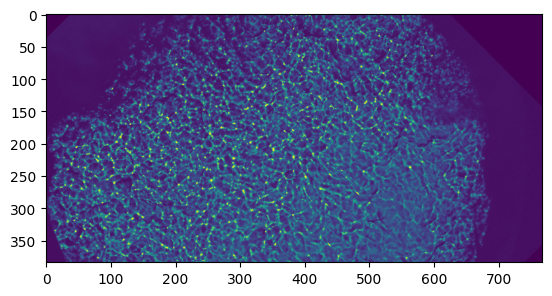

In [6]:
plt.imshow(segment[0].get())

In [7]:
segment[0,0,0]

array(0.)

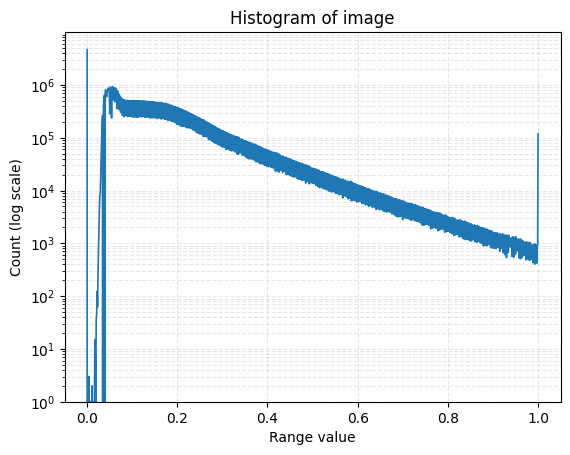

In [8]:
imhist(segment.get(), log=True)

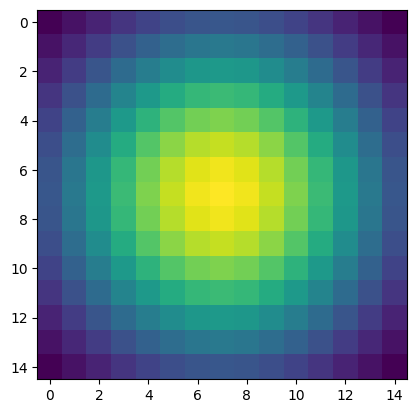

In [9]:
from OSCC_postprocessing.filters.convolution_2d import *

gaussfilt_kernel =  build_2d_kernel("gaussian", ksize, sigma)
gaussfilt_kernel2 = build_2d_kernel("gaussian", 5* ksize, 5* sigma)
plt.imshow(gaussfilt_kernel2)

In [10]:
from OSCC_postprocessing.filters.stdfilt import *

std_filtered_vid = stdfilt(segment, ksize=std_filt_ksize)
std_filtered_vid[segment==0.0] = 0.0

filtered_vid = convolution_2D_auto(std_filtered_vid, gaussfilt_kernel)
foreground = _min_max_scale(filtered_vid)



In [36]:
play_videos_side_by_side((segment.get(), robust_scale(std_filtered_vid, 1, 99.99).get(), foreground.get()))

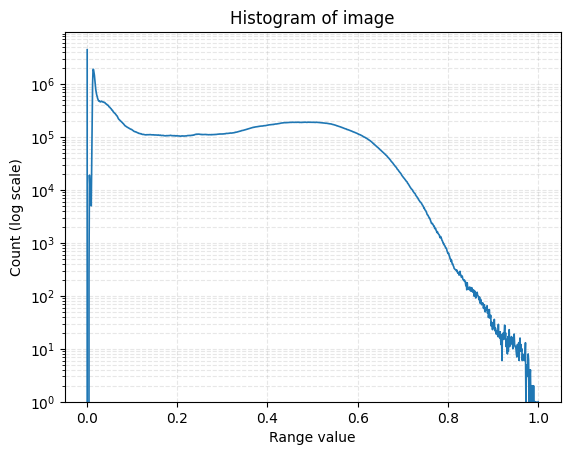

In [11]:
imhist(foreground.get(), log=True)

In [12]:

play_video_cv2(foreground.get())

In [13]:
x = foreground.astype(cp.float32)

# 先做輕微平滑，減少局部噪聲對閾值的影響
# 這裡只是示意，若你在 CPU 可用 cv2.GaussianBlur
# x_blur = cp.asarray(cv2.GaussianBlur(cp.asnumpy(x), (0, 0), 3))

flat = x.ravel()
valid = flat[flat > 0.02]

med = cp.median(valid)
mad = cp.median(cp.abs(valid - med))
sigma = 1.4826 * mad

# 可以把係數調大一點，讓閾值更保守
t = med - n_sigma * sigma
bw = x < t


In [14]:
sigma

array(0.26824555, dtype=float32)

In [15]:
play_video_cv2(255.0*bw.get().astype(np.uint8))

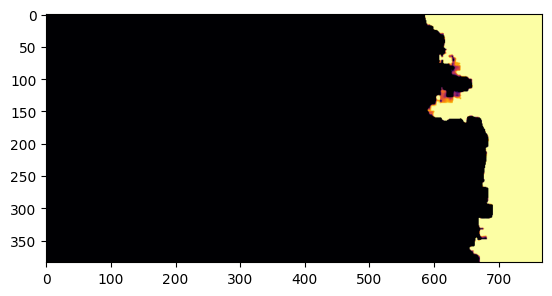

In [16]:
from OSCC_postprocessing.binary_ops.connected_components import *
bw_before_SOI = keep_largest_component_nd_cuda(bw[:bkg_frame_limit])

chamber_score = cp.mean(bw_before_SOI, axis=0)

plt.imshow(chamber_score.get(), cmap='inferno')

In [17]:
import scipy.ndimage as ndi      # CPU 版本
import cupyx.scipy.ndimage as cndi # GPU 版本 (CuPy eXtensions)

se = cp.ones((11, 11), dtype=bool)

bw_chamber = (chamber_score > 0.5).astype(cp.bool_)
bw_chamber = cndi.binary_closing(bw_chamber, structure=se)
bw_chamber = cndi.binary_fill_holes(bw_chamber)
# Hard-coded central area = true
bw_chamber[H//2-50:H//2+50, W//2-300:W//2-100] = False
bw_chamber[H//2-70:H//2+70, W//2-100:W//2] = False
bw_chamber[H//2-100:H//2+100, W//2:W//2+100] = False
bw_chamber[H//2-125:H//2+125, W//2+100:W//2+150] = False
bw_chamber[H//2-150:H//2+150, W//2+150:650] = False

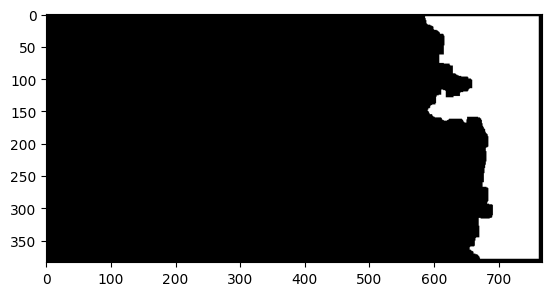

In [18]:
plt.imshow(bw_chamber.get(), cmap='gray')

In [19]:
mask = ~bw_chamber

bw_spray = bw & mask[None, :, :]

In [20]:
play_video_cv2(255.0*bw_spray.get())

In [21]:
bw_spray_largest_blob = keep_largest_component_nd_cuda(bw_spray)
bw_spray_largest_blob = cndi.binary_opening(bw_spray_largest_blob, structure=cp.ones((5,5,5)))

In [22]:
# play_videos_side_by_side((segment.get(), std_filtered_vid.get(), 255.0*bw.get(), 255.0*bw_spray_largest_blob.get()))

In [23]:
# Check for regional Properties in 3D
# Get label image to reconstruct blobs
props, labels = regionprops_3d(bw_spray_largest_blob, connectivity=2, return_labels=True, centroid=True)

# Find the L2 distance for each 3D blob from the y = H//2 axis
props["y-dist"] = np.abs(props["centroid_1"] - bw_spray_largest_blob.shape[1]//2)

# Distance based filtering
filtered_props = props[props["y-dist"] <= maximum_bw_spray_tolerance_y_axis]



# Fall back to all regions when no 3D blob passes the y-axis proximity filter.
if len(filtered_props) == 0:
    filtered_props = props.copy()

# Retain the largest blob
filtered_props = filtered_props.sort_values("volume", ascending=False)

# Get the value from the "label" column of the first row (at position 0)
label_id = filtered_props.iloc[0]["label"]

# Reconstruct the video based on filtered labels
largest_blob = reconstruct_blob(labels, label_id)


In [24]:
for f in range(bkg_frame_limit+5, F):
    largest_blob[f] = keep_largest_component_cuda(largest_blob[f])



In [35]:
play_videos_side_by_side((segment.get(), robust_scale(std_filtered_vid, 1, 99.99).get(), 255.0*largest_blob.get()))

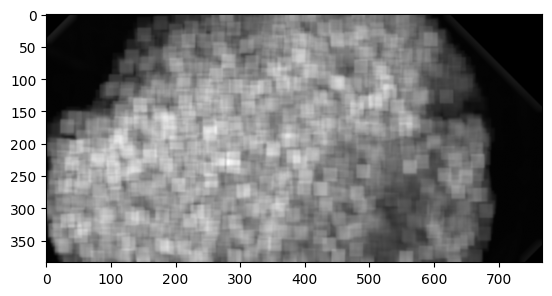

In [26]:
plt.imshow(foreground[20].get(), cmap='gray')

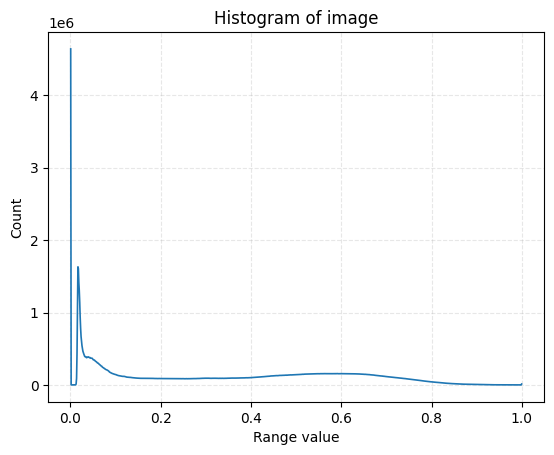

In [34]:
imhist(robust_scale(std_filtered_vid, 1, 99.99).get(), log=False)